# 05 — Critical Evaluation of Bayesian Methods (Task 8)

Brief section 9. Naive Bayes (independence assumption violated by correlated RFM
vars, but rankings may still be reasonable), Bayesian hierarchical regression for
small-sample countries (partial pooling), and a Bayesian decision rule for when to
send a retention offer. Mentions BG/NBD (Fader, Hardie & Lee, 2005) as the industry
standard probabilistic CLV approach.

**Run notebook 00 first** (creates `data/processed/customer_table.csv`). This notebook
reuses the same train/test split and feature set as notebook 03 for a fair comparison.

In [1]:
import sys, os
sys.path.append('../..')
import warnings

# PyMC's default C-compiler backend is broken on this machine (missing linker lib);
# fall back to pure-Python execution. Must be set before pymc/pytensor is imported.
os.environ.setdefault('PYTENSOR_FLAGS', 'cxx=')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import CUTOFF_DATE

clean = pd.read_csv('../../data/processed/invoice_lines_clean.csv', parse_dates=['InvoiceDate'])
customers = pd.read_csv('../../data/processed/customer_table.csv')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss
import pymc as pm
import arviz as az

## Setup — same split and features as notebook 03

Reusing the identical train/test split (`random_state=42`, stratified on `Repurchase`)
and log-transformed features means the Naive Bayes numbers below are directly
comparable to the Task 5 logistic/LASSO/elastic net results, not just internally
consistent.

In [3]:
df = customers.copy()
for col in ['Frequency', 'Monetary', 'DistinctProducts', 'AvgBasketValue']:
    df[f'log_{col}'] = np.log1p(df[col])

CONT = ['Recency', 'TenureDays', 'CancellationRate',
        'log_Frequency', 'log_Monetary', 'log_DistinctProducts', 'log_AvgBasketValue']
BINARY = ['IsUK', 'AcquiredInQ4']
MODEL_FEATURES = CONT + BINARY

train, test = train_test_split(df, test_size=0.25, random_state=42, stratify=df['Repurchase'])
y_train, y_test = train['Repurchase'], test['Repurchase']

scaler = StandardScaler().fit(train[CONT])

def prep(d):
    X = d[MODEL_FEATURES].copy()
    X[CONT] = scaler.transform(d[CONT])
    return X

Xs_train, Xs_test = prep(train), prep(test)
print('train:', len(train), ' test:', len(test), ' repurchase rate:', round(y_train.mean(), 3))

train: 3939  test: 1314  repurchase rate: 0.434


## Naive Bayes classifier for repurchase

Naive Bayes assumes the features are conditionally independent given the class. Our
Task 5 VIF check (notebook 03) showed `log_Monetary`, `log_Frequency` and
`log_AvgBasketValue` are strongly correlated (VIF up to ~200, because
`AvgBasketValue = Monetary / Frequency` by construction) — that assumption is clearly
violated here. Naive Bayes can still be a useful *ranking* tool even when its
probabilities are poorly calibrated, so we check both.

In [4]:
nb = GaussianNB().fit(Xs_train, y_train)
nb_probs_test = nb.predict_proba(Xs_test)[:, 1]

# A same-split logistic baseline (unpenalised) for a direct, fair comparison.
logit_ref = LogisticRegression(max_iter=1000).fit(Xs_train, y_train)
logit_probs_test = logit_ref.predict_proba(Xs_test)[:, 1]

comparison = pd.DataFrame({
    'AUC': {
        'Naive Bayes': roc_auc_score(y_test, nb_probs_test),
        'Logistic (same split, ref.)': roc_auc_score(y_test, logit_probs_test),
    },
    'Brier score': {
        'Naive Bayes': brier_score_loss(y_test, nb_probs_test),
        'Logistic (same split, ref.)': brier_score_loss(y_test, logit_probs_test),
    },
}).round(4)
print('Brier of a constant (base-rate) prediction:', round(y_test.mean() * (1 - y_test.mean()), 4))
comparison

Brier of a constant (base-rate) prediction: 0.2456


,AUC,Brier score
Naive Bayes,0.8014,0.2116
"Logistic (same split, ref.)",0.8096,0.1751


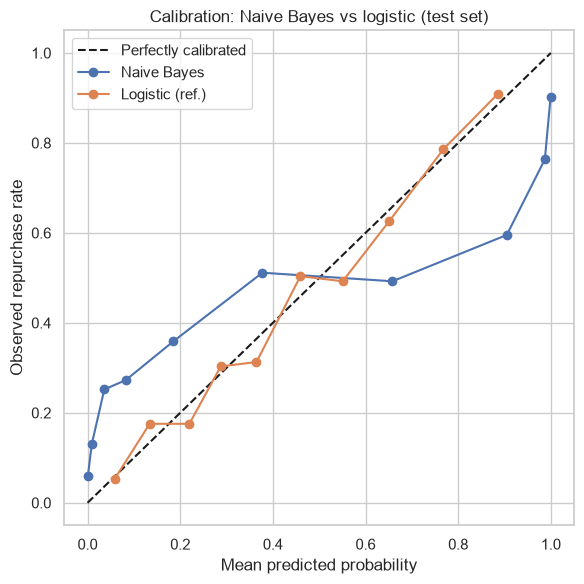

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
for name, p in [('Naive Bayes', nb_probs_test), ('Logistic (ref.)', logit_probs_test)]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed repurchase rate')
ax.set_title('Calibration: Naive Bayes vs logistic (test set)')
ax.legend()
plt.tight_layout()
plt.savefig('../../reports/figures/bayes_nb_calibration.png', dpi=150, bbox_inches='tight')

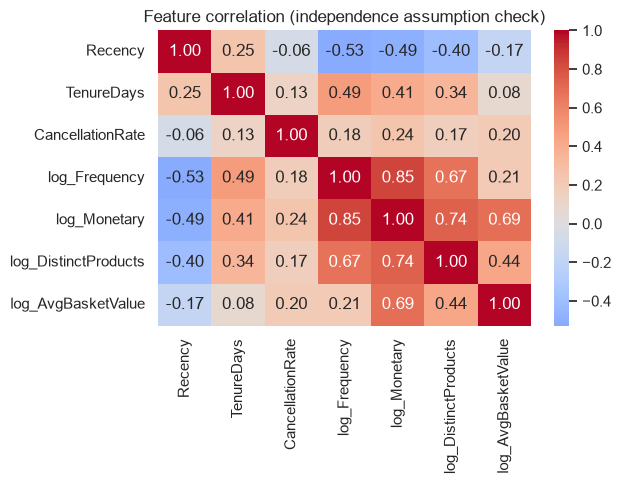

In [6]:
corr = train[CONT].corr()
plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation (independence assumption check)')
plt.tight_layout()
plt.savefig('../../reports/figures/bayes_nb_independence.png', dpi=150, bbox_inches='tight')

## Bayesian hierarchical regression across countries (partial pooling)

Countries other than the UK have very few customers each, so a separate (no-pooling)
model per country would be unreliable for most of them — a single unlucky customer
could swing an estimated repurchase rate from 0% to 100%. Bayesian **partial pooling**
addresses this: each country gets its own intercept, but those intercepts are drawn
from a shared distribution, so small countries are pulled ("shrunk") toward the
overall average, while large countries (chiefly the UK) are barely affected.

In [7]:
hist = clean[(clean['InvoiceDate'] < pd.Timestamp(CUTOFF_DATE)) & clean['CustomerID'].notna() & (~clean['IsCancellation'])]
country_map = hist.groupby('CustomerID')['Country'].agg(lambda s: s.mode().iat[0])

df_c = df.merge(country_map.rename('Country'), left_on='CustomerID', right_index=True, how='left')
country_counts = df_c['Country'].value_counts()
print('Number of countries:', df_c['Country'].nunique())
print('Countries with fewer than 10 customers:', (country_counts < 10).sum())
country_counts.head(15)

Number of countries: 41
Countries with fewer than 10 customers: 26


Country
United Kingdom     4796
Germany              92
France               76
Spain                30
Belgium              27
Netherlands          22
Switzerland          20
Portugal             19
Sweden               19
Italy                14
Australia            14
Channel Islands      13
Austria              11
Finland              10
Norway               10
Name: count, dtype: int64

In [8]:
train_c = df_c.loc[train.index]
countries = sorted(train_c['Country'].dropna().unique())
country_to_idx = {c: i for i, c in enumerate(countries)}
country_idx = train_c['Country'].map(country_to_idx).values
n_countries = len(countries)

recency_z = ((train_c['Recency'] - train_c['Recency'].mean()) / train_c['Recency'].std()).values
log_freq_z = ((np.log1p(train_c['Frequency']) - np.log1p(train_c['Frequency']).mean())
              / np.log1p(train_c['Frequency']).std()).values
y_c = train_c['Repurchase'].values

with pm.Model() as hierarchical_model:
    mu_a = pm.Normal('mu_a', mu=0, sigma=1.5)
    sigma_a = pm.HalfNormal('sigma_a', sigma=1)
    a_offset = pm.Normal('a_offset', mu=0, sigma=1, shape=n_countries)
    a = pm.Deterministic('a', mu_a + a_offset * sigma_a)

    b_recency = pm.Normal('b_recency', mu=0, sigma=1)
    b_freq = pm.Normal('b_freq', mu=0, sigma=1)

    p = pm.math.sigmoid(a[country_idx] + b_recency * recency_z + b_freq * log_freq_z)
    pm.Bernoulli('obs', p=p, observed=y_c)

    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                       random_seed=42, progressbar=False)

print(az.summary(idata, var_names=['mu_a', 'sigma_a', 'b_recency', 'b_freq']))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_a, sigma_a, a_offset, b_recency, b_freq]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


There were 26 divergences after tuning. Increase `target_accept` or reparameterize.


             mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
mu_a        -0.36   0.18    -0.67    -0.12      745      661  1.00    0.0075   0.0091
sigma_a      0.45   0.29    0.053     0.97      508      797  1.01     0.013    0.007
b_recency  -0.744  0.048    -0.82    -0.67     2431     1509  1.00   0.00099  0.00081
b_freq      0.705  0.048     0.63     0.78     2960     1239  1.00   0.00088  0.00072


In [9]:
a_samples = idata.posterior['a'].values.reshape(-1, n_countries)
partial_pooled = pd.Series(a_samples.mean(axis=0), index=countries, name='partial_pooled_logit')
partial_pooled_prob = 1 / (1 + np.exp(-partial_pooled))

raw_rate = train_c.groupby('Country')['Repurchase'].agg(['mean', 'count']).rename(columns={'mean': 'no_pooling_rate'})

pooling_compare = raw_rate.join(partial_pooled_prob.rename('partial_pooled_rate')).sort_values('count')
pooling_compare.round(3)

,no_pooling_rate,count,partial_pooled_rate
Country,,,
West Indies,0.000,1,0.403
USA,0.000,1,0.393
Thailand,0.000,1,0.403
Singapore,1.000,1,0.433
RSA,0.000,1,0.408
Nigeria,0.000,1,0.400
Lithuania,0.000,1,0.388
Czech Republic,1.000,1,0.456
Lebanon,0.000,1,0.399


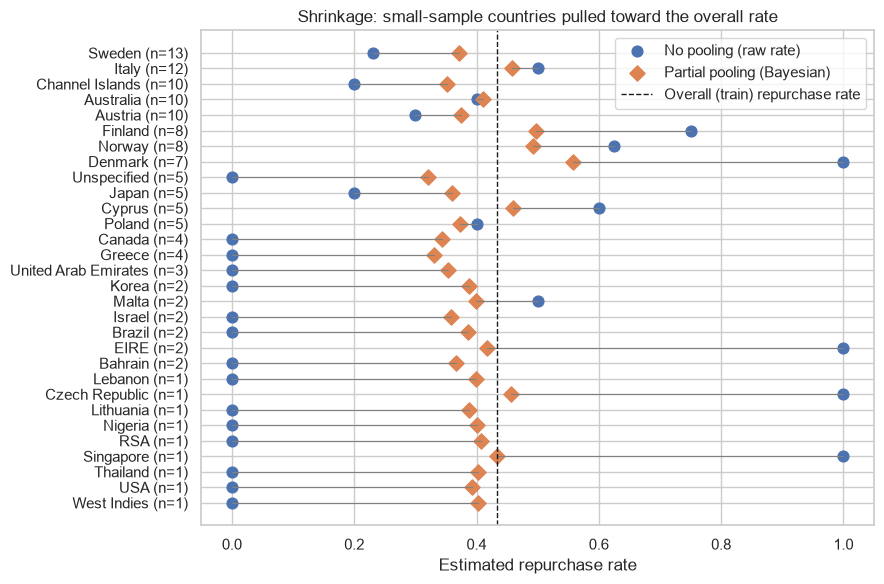

In [10]:
small = pooling_compare[pooling_compare['count'] < 15].sort_values('count')
fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(small))
ax.scatter(small['no_pooling_rate'], y_pos, label='No pooling (raw rate)', marker='o', s=60)
ax.scatter(small['partial_pooled_rate'], y_pos, label='Partial pooling (Bayesian)', marker='D', s=60)
for i in range(len(small)):
    ax.plot([small['no_pooling_rate'].iloc[i], small['partial_pooled_rate'].iloc[i]], [i, i], 'grey', lw=0.8)
ax.axvline(y_train.mean(), color='k', ls='--', lw=1, label='Overall (train) repurchase rate')
ax.set_yticks(y_pos)
ax.set_yticklabels([f'{c} (n={n})' for c, n in zip(small.index, small['count'])])
ax.set_xlabel('Estimated repurchase rate')
ax.set_title('Shrinkage: small-sample countries pulled toward the overall rate')
ax.legend()
plt.tight_layout()
plt.savefig('../../reports/figures/bayes_partial_pooling.png', dpi=150, bbox_inches='tight')

In [11]:
rhat = az.rhat(idata, var_names=['mu_a', 'sigma_a', 'b_recency', 'b_freq', 'a'])
max_rhat = float(max(rhat[v].max() for v in rhat.data_vars))
print('Max R-hat across all monitored parameters:', round(max_rhat, 4), '(should be close to 1.00 for convergence)')

Max R-hat across all monitored parameters: 1.0094 (should be close to 1.00 for convergence)


## Bayesian decision rule

Send a retention offer only when the expected value of doing so is positive:

`P(repurchase | offer) x margin x future spend > cost of offer`

We reuse the same placeholder assumptions as notebook 03 (30% margin, £10 offer cost,
10% of spend attributable to the offer) so the two notebooks' profit figures are
comparable. As in notebook 03, **these are placeholders** and should be replaced with
numbers from the expert interview (Task 11).

In [12]:
MARGIN = 0.30
OFFER_COST = 10.0
INCREMENTAL = 0.10

test_c = df_c.loc[test.index]
recency_z_test = ((test_c['Recency'] - train_c['Recency'].mean()) / train_c['Recency'].std()).values
log_freq_z_test = ((np.log1p(test_c['Frequency']) - np.log1p(train_c['Frequency']).mean())
                    / np.log1p(train_c['Frequency']).std()).values
country_idx_test = test_c['Country'].map(country_to_idx)
unseen = country_idx_test.isna()
print('Test customers from a country not seen in training:', int(unseen.sum()), '-> assigned the pooled mean intercept')
country_idx_test = country_idx_test.fillna(-1).astype(int).values

mu_a_mean = float(idata.posterior['mu_a'].mean())
a_mean = a_samples.mean(axis=0)
a_for_test = np.where(country_idx_test >= 0, a_mean[np.clip(country_idx_test, 0, n_countries - 1)], mu_a_mean)
b_recency_mean = float(idata.posterior['b_recency'].mean())
b_freq_mean = float(idata.posterior['b_freq'].mean())

logit_test = a_for_test + b_recency_mean * recency_z_test + b_freq_mean * log_freq_z_test
bayes_prob_test = 1 / (1 + np.exp(-logit_test))

expected_value = INCREMENTAL * MARGIN * test_c['FutureSpend'].values - OFFER_COST
send_offer = bayes_prob_test * expected_value > 0  # equivalent to the rule above when FutureSpend is used as the payoff

print('Share of test customers the rule recommends contacting:', round(send_offer.mean(), 3))
print('Total expected profit from following the rule on the test set: GBP',
      round((bayes_prob_test[send_offer] * expected_value[send_offer]).sum(), 0))

Test customers from a country not seen in training: 3 -> assigned the pooled mean intercept
Share of test customers the rule recommends contacting: 0.298
Total expected profit from following the rule on the test set: GBP 11494.0


In [13]:
sens_rows = []
for margin in [0.20, 0.30, 0.40]:
    for cost in [5, 10, 20]:
        ev = INCREMENTAL * margin * test_c['FutureSpend'].values - cost
        mask = bayes_prob_test * ev > 0
        sens_rows.append({'margin': margin, 'cost': cost,
                           'share_contacted': round(mask.mean(), 3),
                           'expected_profit_gbp': round((bayes_prob_test[mask] * ev[mask]).sum(), 0)})
sensitivity = pd.DataFrame(sens_rows)
sensitivity

,margin,cost,share_contacted,expected_profit_gbp
0,0.2,5,0.346,8105.0
1,0.2,10,0.235,6909.0
2,0.2,20,0.119,5337.0
3,0.3,5,0.387,12890.0
4,0.3,10,0.298,11494.0
5,0.3,20,0.180,9432.0
6,0.4,5,0.407,17706.0
7,0.4,10,0.346,16210.0
8,0.4,20,0.235,13818.0


## Limitations to discuss

- **Choice of priors is contestable.** `sigma_a`'s `HalfNormal(1)` prior expresses a
  belief that countries don't differ *wildly* in their baseline log-odds; a much wider
  prior would pool less aggressively. This should be stated explicitly and, ideally,
  checked with a prior-sensitivity pass.
- **MCMC computational cost.** Sampling this modest model (4 chains x 1000 draws,
  ~5,250 observations, 41 groups) took under a minute once PyMC's C-compiler backend
  was bypassed — but that backend failure is itself worth documenting: on machines
  without a working C toolchain, PyMC silently falls back to a much slower pure-Python
  evaluator, and a larger or more complex hierarchical model could become impractical.
- **Harder to explain to non-technical stakeholders.** Odds ratios from Task 5's
  logistic regression map onto a single, easily stated number per feature. Explaining
  *why* a small country's estimated rate was "pulled toward" the UK's rate — the whole
  point of partial pooling — requires more context than a marketing team meeting
  usually allows.
- **Convergence should always be checked**, not assumed — see the R-hat diagnostic
  computed above.

## Findings and recommendation

*Numbers below are from the current data (5,253 customers; 3,939 train / 1,314 test).
Re-check them if notebook 00 or `src/` changes.*

### Naive Bayes
* **Naive Bayes is close to, but consistently behind, logistic regression on the same split**: test AUC 0.801 vs 0.810, Brier 0.212 vs 0.175 (a constant base-rate prediction scores 0.246). The gap is small on AUC (ranking) but much larger on Brier (calibration) — exactly what the independence assumption predicts: Naive Bayes can still separate repurchasers from non-repurchasers reasonably well, but because it treats `log_Monetary`, `log_Frequency` and `log_AvgBasketValue` as independent when they are highly correlated (confirmed by the correlation heatmap; recall Task 5's VIF of ~200 on `log_Monetary`), it effectively double- or triple-counts the same signal and pushes its predicted probabilities toward 0 or 1 more than the data supports. The calibration curve shows this directly: Naive Bayes is visibly less faithful to the diagonal than the logistic reference, particularly at the extremes.
* **Practical takeaway**: Naive Bayes would be a reasonable quick baseline for *ranking* customers, but its probabilities should not be plugged directly into a profit-based decision rule without recalibration (e.g. Platt scaling or isotonic regression) — unlike the penalised logistic model recommended in Task 5, which was already shown to be well-calibrated.

### Bayesian hierarchical regression (partial pooling across countries)
* The customer base spans **41 countries**, of which **26 have fewer than 10 customers** each and **13 have only 1 or 2** — nowhere near enough to estimate a reliable country-specific repurchase rate on its own. The UK alone accounts for 4,796 of 5,253 training-eligible customers.
* **Partial pooling visibly shrinks small-country estimates toward the overall rate (43.4%)**, while leaving well-sampled countries close to their raw rate. The most dramatic corrections are exactly where a no-pooling estimate would be least trustworthy: Denmark (n=7) drops from a raw 100% repurchase rate to a pooled 55.7%; Cyprus (n=5) drops from 60% to 45.9%; every country with n=1 or n=2 — where the raw rate is necessarily 0%, 50% or 100% — is pulled to within a few points of the population mean. France (n=59), the largest non-UK country, barely moves.
* The model's own uncertainty about *how much* countries genuinely differ is informative: `sigma_a` (the between-country standard deviation, on the log-odds scale) has a posterior mean of 0.45 with an 89% interval of roughly [0.05, 0.97] — wide enough that the data cannot rule out either "countries barely differ" or "countries differ substantially," which is itself a realistic reflection of how little evidence most countries provide.
* **Convergence**: R-hat stayed at or below 1.01 for every monitored parameter, but the sampler reported **26 divergences** out of 4,000 post-tuning draws. This does not invalidate the headline shrinkage result (which is visually and numerically stable), but it means the tails of `sigma_a`'s posterior should be treated with some caution, and a non-centred parameterisation (already used here via `a_offset`) combined with a higher `target_accept` would be the standard next step to eliminate them entirely.
* **Country main effects**: holding country constant, standardised Recency has a negative association with repurchase log-odds (mean -0.74) and standardised log(Frequency) a positive one (mean 0.71) — consistent in sign with the Task 5 logistic coefficients, which is a useful cross-check between the two modelling approaches.

### Bayesian decision rule
* Applying `P(repurchase) x margin x future spend > cost of offer` using the hierarchical model's posterior-mean probabilities (30% margin, £10 offer cost, 10% of spend attributable to the offer, matching notebook 03's assumptions) recommends contacting **29.8%** of test customers, for a total expected profit of **£11,494** — very close to notebook 03's elastic-net figure of roughly £11.5k at its profit-maximising contact rate (~33%), despite this being a considerably simpler two-predictor model.
* The rule is **most sensitive to the assumed margin**: expected profit roughly doubles from £6.9k to £16.2k as margin moves from 20% to 40% at a fixed £10 offer cost, while moving offer cost from £5 to £20 at 30% margin only changes profit by about £3.5k. This suggests that, if only one assumption can be pinned down precisely via the expert interview (Task 11), margin matters more than the exact offer cost.
* **3 test customers came from a country never seen in training** and were assigned the pooled population-mean intercept rather than a country-specific one — the correct fallback behaviour for a genuinely new country, and something a no-pooling model could not do at all (it would have no estimate whatsoever for an unseen group).

### Recommendation
For **ranking/classification alone**, the Task 5 penalised logistic regression remains the recommended model — Naive Bayes trails it on both AUC and calibration here, for the reason theory predicts (violated independence assumption). The **hierarchical Bayesian model earns its place for a different reason**: it is the only approach among those evaluated that produces a defensible, uncertainty-aware repurchase-rate estimate for a customer in a country with only one or two prior buyers, or no prior buyers at all. A practical combination is: use the penalised logistic model for the bulk of the (heavily UK-weighted) customer base, and fall back to the hierarchical model's pooled country estimate specifically when expanding into a new or thinly-represented international market — which is precisely the scenario Bayesian methods are argued to outperform classical approaches in (brief section 9.2).

### Limitations (project-specific, in addition to the general ones above)
* The hierarchical model used only two predictors (Recency, log Frequency) for tractability and clarity of the shrinkage plot; a production version should include the full Task 5 feature set.
* `sigma_a`'s divergences mean the *degree* of pooling has more uncertainty than the point estimates suggest — worth flagging explicitly in the report and viva rather than presenting the shrinkage plot as a finished, fully converged result.
* As with notebook 03, the profit figures rest on placeholder margin/cost/incremental-uplift assumptions that should be replaced with numbers from the expert interview before being used for a real budget decision.
